In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  


In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Columns Description
Pregnancies: The number of times the patient has been pregnant.
Glucose:he plasma glucose concentration after a 2-hour oral glucose tolerance test (OGTT).
BloodPressure:Diastolic blood pressure (measured in mm Hg)
SkinThickness:Triceps skinfold thickness (measured in mm).
Insulin: 2-Hour serum insulin (measured in $\mu\text{U/mL}$).
BMI:Body Mass Index, calculated as weight in kilograms divided by height in meters squared:
DiabetesPedigreeFunction:A calculated score that scores the genetic risk of diabetes based on the patient's family history.
Age:The age of the patient in years.

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pregnancies', ylabel='Density'>

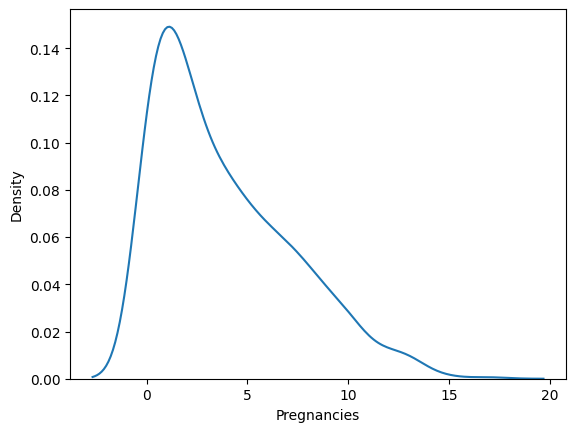

In [7]:
sns.kdeplot(data = df, x=df['Pregnancies'])

In [8]:
df[df['Glucose'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [9]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)

In [10]:
df['Glucose'].isnull().sum()

5

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Glucose', ylabel='Density'>

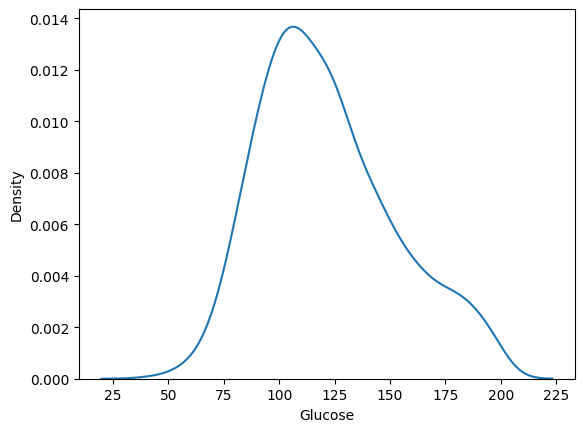

In [11]:
sns.kdeplot(data = df, x = df['Glucose'])

In [12]:
X = df.drop('Outcome',axis =1)

In [13]:
y = df['Outcome']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)


In [15]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit(X_train[['Glucose']])
X_train['Glucose'] = imp_mean.transform(X_train[['Glucose']])
X_test['Glucose'] = imp_mean.transform(X_test[['Glucose']])

In [16]:
X_train[X_train['Glucose'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


In [17]:
X_train[X_train['BloodPressure'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,0,0,0,0.0,0.304,21
535,4,132.0,0,0,0,32.9,0.302,23
357,13,129.0,0,30,0,39.9,0.569,44
703,2,129.0,0,0,0,38.5,0.304,41
619,0,119.0,0,0,0,32.4,0.141,24
266,0,138.0,0,0,0,36.3,0.933,25
643,4,90.0,0,0,0,28.0,0.610,31
15,7,100.0,0,0,0,30.0,0.484,32
589,0,73.0,0,0,0,21.1,0.342,25
453,2,119.0,0,0,0,19.6,0.832,72


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BloodPressure', ylabel='Density'>

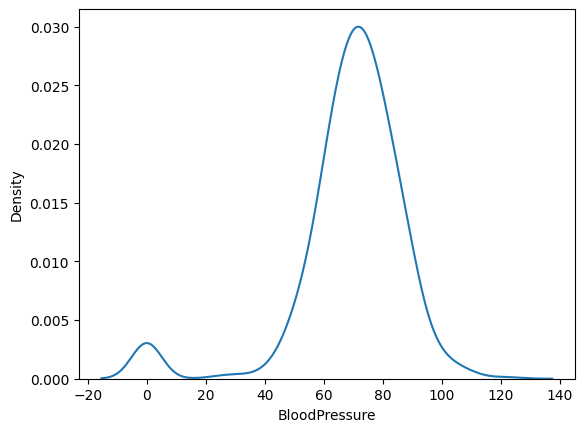

In [35]:
sns.kdeplot(data = X_train, x = 'BloodPressure')

In [39]:
X_train['BloodPressure'] = X_train['BloodPressure'].replace(0, np.nan)

In [41]:
X_train['BloodPressure'].isnull().sum()

24

In [43]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit(X_train[['BloodPressure']])
X_train['BloodPressure'] = imp_mean.transform(X_train[['BloodPressure']])
X_test['BloodPressure'] = imp_mean.transform(X_test[['BloodPressure']])

In [45]:
X_train['BloodPressure'].isnull().sum()

0

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BloodPressure', ylabel='Density'>

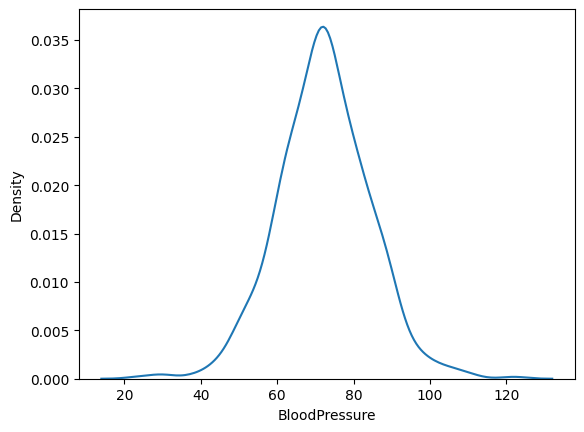

In [47]:
sns.kdeplot(data = X_train, x = 'BloodPressure')

In [49]:
X_train[X_train['BMI'] == 0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,72.238983,0,0,0.0,0.304,21
145,0,102.0,75.000000,23,0,0.0,0.572,21
426,0,94.0,72.238983,0,0,0.0,0.256,25
9,8,125.0,96.000000,0,0,0.0,0.232,54
522,6,114.0,72.238983,0,0,0.0,0.189,26
371,0,118.0,64.000000,23,89,0.0,1.731,21
684,5,136.0,82.000000,0,0,0.0,0.640,69


In [51]:
X_train['BMI'] = X_train['BMI'].replace(0, np.nan)

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BMI', ylabel='Density'>

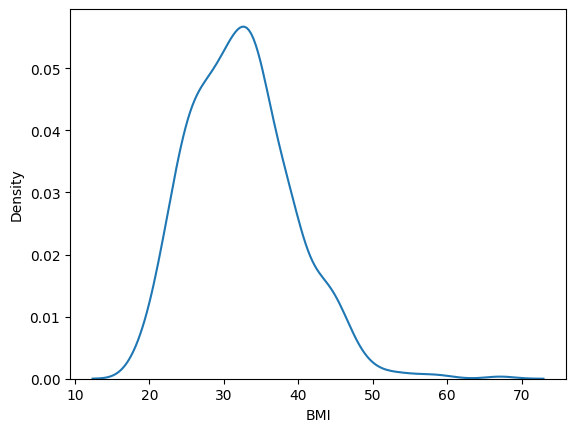

In [53]:
sns.kdeplot(data = X_train, x = 'BMI')

In [55]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mean.fit(X_train[['BMI']])
X_train['BMI'] = imp_mean.transform(X_train[['BMI']])
X_test['BMI'] = imp_mean.transform(X_test[['BMI']])

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='BMI', ylabel='Density'>

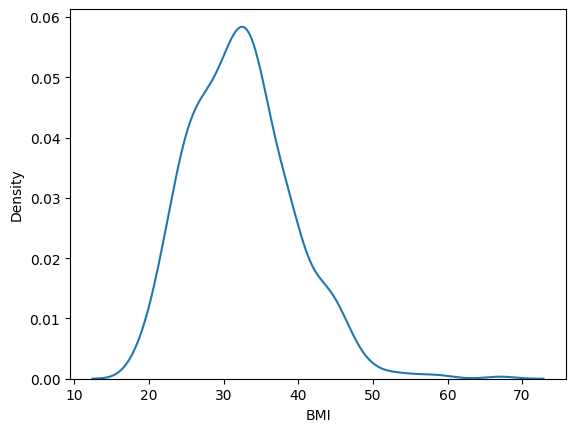

In [57]:
sns.kdeplot(data = X_train, x = 'BMI')

In [61]:
X_train['Age_Group'] = None

In [65]:
bins = [0,29,50, float('inf')]

In [67]:
labels = ['Young','Adult','Senior']

In [77]:
X_train['Age_Group'] = pd.cut(X_train['Age'], bins = bins, labels=labels)

In [81]:
X_test['Age_Group'] = pd.cut(X_test['Age'], bins = bins, labels=labels)

In [79]:
X_train.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Age_Group
60,2,84.0,72.238983,0,0,32.0,0.304,21,Young
618,9,112.0,82.000000,24,0,28.2,1.282,50,Adult
346,1,139.0,46.000000,19,83,28.7,0.654,22,Young
294,0,161.0,50.000000,0,0,21.9,0.254,65,Senior
231,6,134.0,80.000000,37,370,46.2,0.238,46,Adult


In [85]:
from sklearn.preprocessing import OrdinalEncoder
pclass_encoder = OrdinalEncoder(categories=[['Young','Adult','Senior']])
pclass_encoder.fit(X_train[['Age_Group']])
X_train['Age_Group'] = pclass_encoder.transform(X_train[['Age_Group']])
pclass_encoder.transform(X_test[['Age_Group']])

array([[1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [2.],
       [0.],
       [1.],
       [1.],
       [2.],
       [1.],
       [2.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [2.],
       [1.],
       [1.],
       [2.],
       [1.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [2.],
       [2.],
       [1.],
       [0.],
       [0.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [0.],
       [0.],
       [0.],
       [2.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [2.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [2.],
       [0.],
       [0.],
       [2.],
       [2.],